In [2]:
import sys

sys.executable

'/home/luis/proyectos/analisis-financiero/.venv/bin/python'

In [3]:
import yfinance as yf
import pandas as pd

nvda = yf.download(
    "NVDA",
    period="1y",
    interval="1d"
)

nvda.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2025-07-17,172.769897,173.928358,170.602786,171.791205,160841100
2025-07-18,172.180679,174.018228,171.032200,173.409039,146456400
2025-07-21,171.152054,173.149394,170.772554,172.520227,123126100
2025-07-22,166.807831,171.162032,164.361093,171.112096,193114300
2025-07-23,170.552856,171.032214,167.746596,169.304519,154082200


In [4]:
nvda.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-07-17 to 2026-07-16
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   251 non-null    float64
 1   (High, NVDA)    251 non-null    float64
 2   (Low, NVDA)     251 non-null    float64
 3   (Open, NVDA)    251 non-null    float64
 4   (Volume, NVDA)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [5]:
nvda.describe()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,188.875768,191.572978,186.046504,188.985545,1.730080e+08
std,13.864857,14.332822,13.458355,13.926720,4.592427e+07
min,164.977722,168.805173,163.851778,166.775632,6.552850e+07
25%,179.271301,182.152617,176.070378,179.321227,1.429456e+08
50%,185.184143,187.770987,182.797047,184.774638,1.647491e+08
75%,197.849548,200.113352,194.196028,196.725599,1.894772e+08
max,235.465576,236.264633,229.033071,229.602402,3.608079e+08


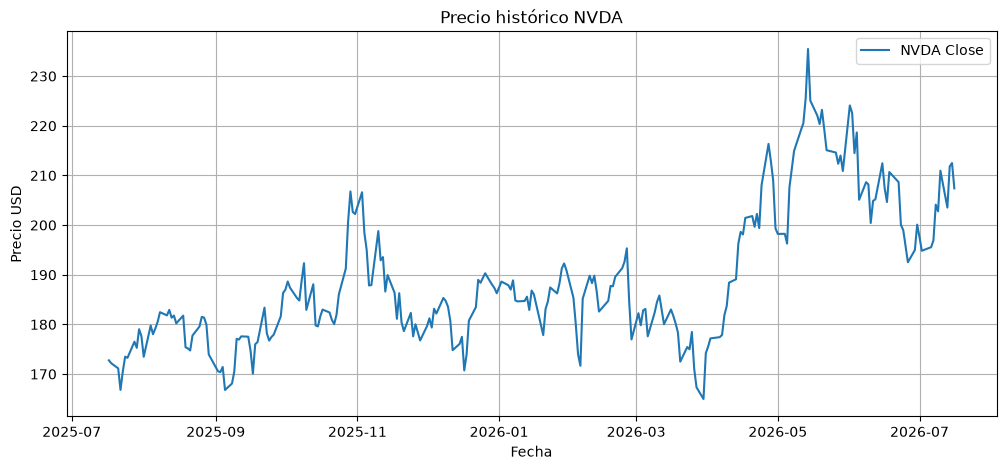

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    nvda["Close"],
    label="NVDA Close"
)

plt.title("Precio histórico NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio USD")

plt.grid(True)
plt.legend()

plt.show()

In [7]:
import yfinance as yf
import pandas as pd

nvda = yf.download(
    "NVDA",
    period="1y",
    interval="1d"
)

nvda.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2025-07-17,172.769897,173.928358,170.602786,171.791205,160841100
2025-07-18,172.180695,174.018244,171.032215,173.409054,146456400
2025-07-21,171.152054,173.149394,170.772554,172.520227,123126100
2025-07-22,166.807846,171.162048,164.361108,171.112111,193114300
2025-07-23,170.552841,171.032198,167.746581,169.304504,154082200


In [8]:
nvda.columns = nvda.columns.droplevel(1)

nvda.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-07-17,172.769897,173.928358,170.602786,171.791205,160841100
2025-07-18,172.180695,174.018244,171.032215,173.409054,146456400
2025-07-21,171.152054,173.149394,170.772554,172.520227,123126100
2025-07-22,166.807846,171.162048,164.361108,171.112111,193114300
2025-07-23,170.552841,171.032198,167.746581,169.304504,154082200


In [11]:
nvda["Return"] = nvda["Close"].pct_change()

nvda.head()

Price,Close,High,Low,Open,Volume,Return
Date,,,,,,
2025-07-17,172.769897,173.928358,170.602786,171.791205,160841100,NaN
2025-07-18,172.180695,174.018244,171.032215,173.409054,146456400,-0.003410
2025-07-21,171.152054,173.149394,170.772554,172.520227,123126100,-0.005974
2025-07-22,166.807846,171.162048,164.361108,171.112111,193114300,-0.025382
2025-07-23,170.552841,171.032198,167.746581,169.304504,154082200,0.022451


In [12]:
volatilidad = nvda["Return"].std() * (252**0.5)

volatilidad

np.float64(0.35883753933106616)

In [14]:
nvda.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return'], dtype='str', name='Price')

In [15]:
nvda["Return"] = nvda["Close"].pct_change()

nvda.head()

Price,Close,High,Low,Open,Volume,Return
Date,,,,,,
2025-07-17,172.769897,173.928358,170.602786,171.791205,160841100,NaN
2025-07-18,172.180695,174.018244,171.032215,173.409054,146456400,-0.003410
2025-07-21,171.152054,173.149394,170.772554,172.520227,123126100,-0.005974
2025-07-22,166.807846,171.162048,164.361108,171.112111,193114300,-0.025382
2025-07-23,170.552841,171.032198,167.746581,169.304504,154082200,0.022451


In [16]:
nvda["Cumulative Return"] = (1 + nvda["Return"]).cumprod() - 1

nvda.tail()

Price,Close,High,Low,Open,Volume,Return,Cumulative Return
Date,,,,,,,
2026-07-10,210.960007,211.000000,201.919998,202.000000,148421000,0.040339,0.221046
2026-07-13,203.529999,210.570007,203.000000,208.539993,121411000,-0.035220,0.178041
2026-07-14,211.800003,212.550003,203.800003,208.199997,124379600,0.040633,0.225908
2026-07-15,212.500000,213.809998,206.039993,211.960007,124797200,0.003305,0.229960
2026-07-16,207.399994,211.080002,205.850006,210.169998,122377500,-0.024000,0.200441


In [17]:
nvda.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return',
       'Cumulative Return'],
      dtype='str', name='Price')

In [18]:
# Retorno promedio diario
retorno_promedio = nvda["Return"].mean()

# Volatilidad diaria
volatilidad_diaria = nvda["Return"].std()

# Volatilidad anualizada
volatilidad_anual = volatilidad_diaria * (252 ** 0.5)

print("Retorno promedio diario:", retorno_promedio)
print("Volatilidad diaria:", volatilidad_diaria)
print("Volatilidad anualizada:", volatilidad_anual)

Retorno promedio diario: 0.0009850038818424375
Volatilidad diaria: 0.022604640241532376
Volatilidad anualizada: 0.35883753933106616


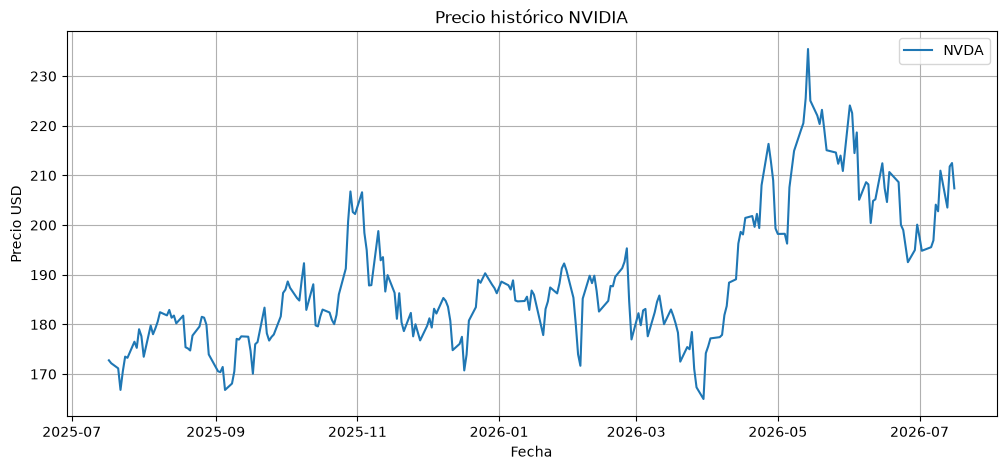

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    nvda.index,
    nvda["Close"],
    label="NVDA"
)

plt.title("Precio histórico NVIDIA")
plt.xlabel("Fecha")
plt.ylabel("Precio USD")

plt.legend()
plt.grid(True)

plt.show()

In [21]:
# Retorno promedio diario
retorno_promedio = nvda["Return"].mean()

# Volatilidad diaria
volatilidad_diaria = nvda["Return"].std()

# Volatilidad anualizada
volatilidad_anual = volatilidad_diaria * (252 ** 0.5)

print("Retorno promedio diario:", retorno_promedio)
print("Volatilidad diaria:", volatilidad_diaria)
print("Volatilidad anualizada:", volatilidad_anual)

Retorno promedio diario: 0.0009850038818424375
Volatilidad diaria: 0.022604640241532376
Volatilidad anualizada: 0.35883753933106616


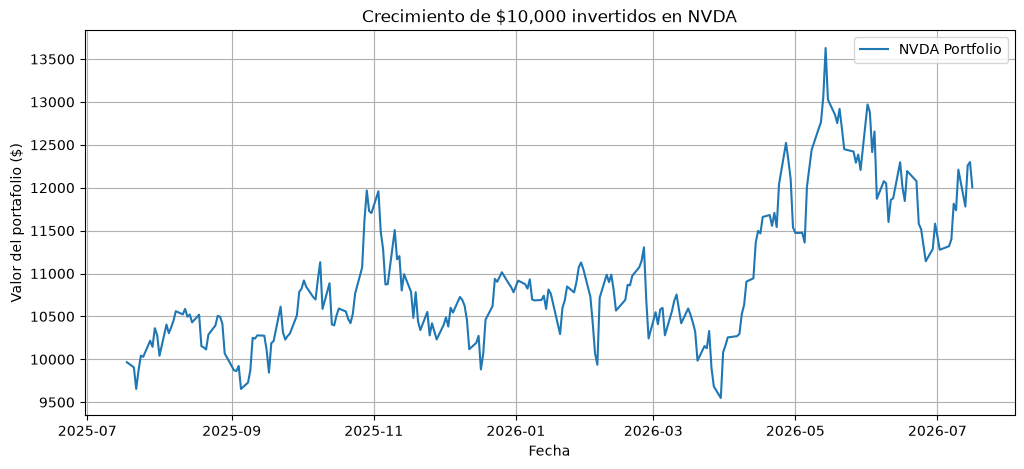

In [22]:
import matplotlib.pyplot as plt

capital_inicial = 10000

nvda["Portfolio"] = capital_inicial * (1 + nvda["Return"]).cumprod()

plt.figure(figsize=(12,5))

plt.plot(
    nvda.index,
    nvda["Portfolio"],
    label="NVDA Portfolio"
)

plt.title("Crecimiento de $10,000 invertidos en NVDA")
plt.xlabel("Fecha")
plt.ylabel("Valor del portafolio ($)")

plt.grid(True)
plt.legend()

plt.show()

In [23]:
nvda[["Close", "Return"]].head(10)

Price,Close,Return
Date,,
2025-07-17,172.769897,NaN
2025-07-18,172.180695,-0.003410
2025-07-21,171.152054,-0.005974
2025-07-22,166.807846,-0.025382
2025-07-23,170.552841,0.022451
2025-07-24,173.508911,0.017332
2025-07-25,173.269226,-0.001381
2025-07-28,176.514893,0.018732
2025-07-29,175.276550,-0.007016


In [24]:
nvda["Portfolio"].tail()

Date
2026-07-10    12210.460839
2026-07-13    11780.408611
2026-07-14    12259.080208
2026-07-15    12299.596349
2026-07-16    12004.405683
Name: Portfolio, dtype: float64

In [25]:
nvda["Portfolio"].iloc[-1]

np.float64(12004.405683193545)

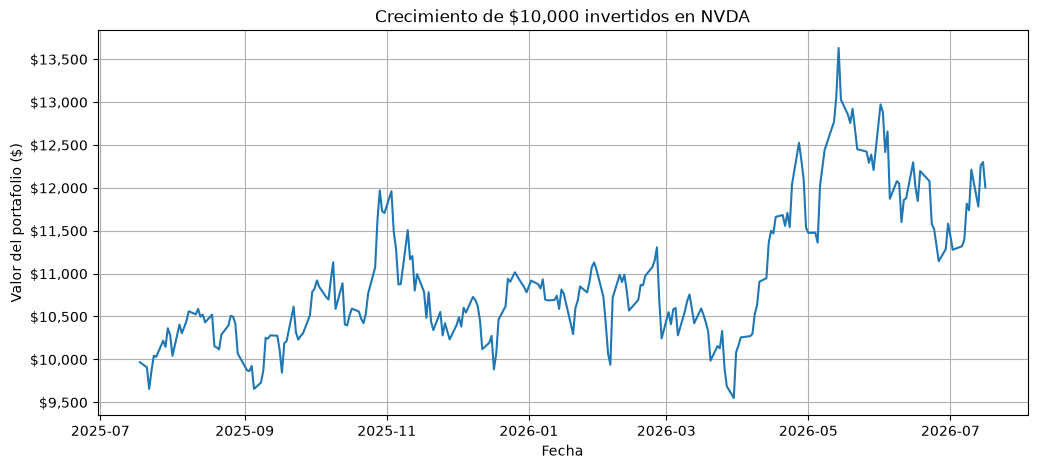

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

capital_inicial = 10000

nvda["Portfolio"] = capital_inicial * (1 + nvda["Return"]).cumprod()

plt.figure(figsize=(12,5))

plt.plot(
    nvda.index,
    nvda["Portfolio"]
)

plt.title("Crecimiento de $10,000 invertidos en NVDA")
plt.ylabel("Valor del portafolio ($)")
plt.xlabel("Fecha")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.grid(True)

plt.show()

In [27]:
nvda["Portfolio"].iloc[-1]

np.float64(12004.405683193545)

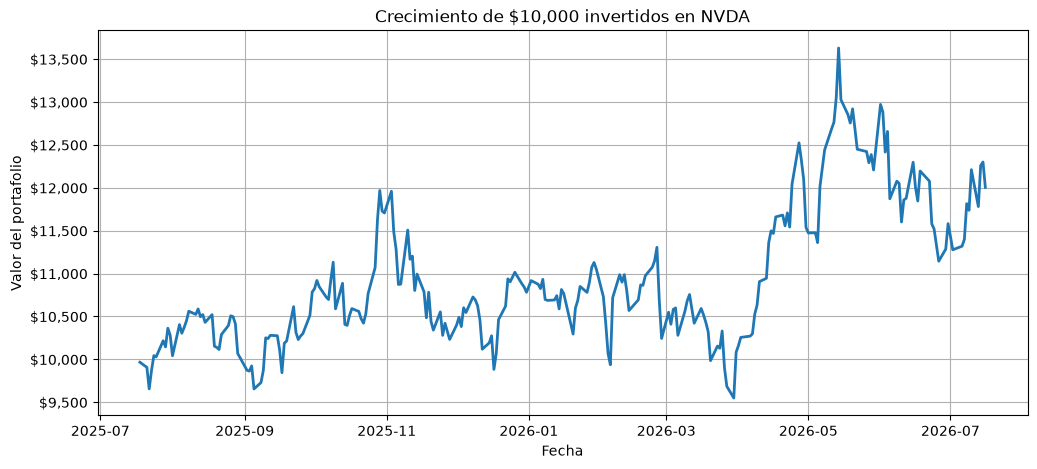

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,5))

plt.plot(
    nvda.index,
    nvda["Portfolio"],
    linewidth=2
)

plt.title("Crecimiento de $10,000 invertidos en NVDA")
plt.xlabel("Fecha")
plt.ylabel("Valor del portafolio")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.grid(True)

plt.show()

In [29]:
nvda["SMA20"] = nvda["Close"].rolling(window=20).mean()

nvda["SMA50"] = nvda["Close"].rolling(window=50).mean()

nvda.head()

Price,Close,High,Low,Open,Volume,Return,Cumulative Return,Portfolio,SMA20,SMA50
Date,,,,,,,,,,
2025-07-17,172.769897,173.928358,170.602786,171.791205,160841100,NaN,NaN,NaN,NaN,NaN
2025-07-18,172.180695,174.018244,171.032215,173.409054,146456400,-0.003410,-0.003410,9965.896670,NaN,NaN
2025-07-21,171.152054,173.149394,170.772554,172.520227,123126100,-0.005974,-0.009364,9906.358477,NaN,NaN
2025-07-22,166.807846,171.162048,164.361108,171.112111,193114300,-0.025382,-0.034509,9654.913762,NaN,NaN
2025-07-23,170.552841,171.032198,167.746581,169.304504,154082200,0.022451,-0.012832,9871.675778,NaN,NaN


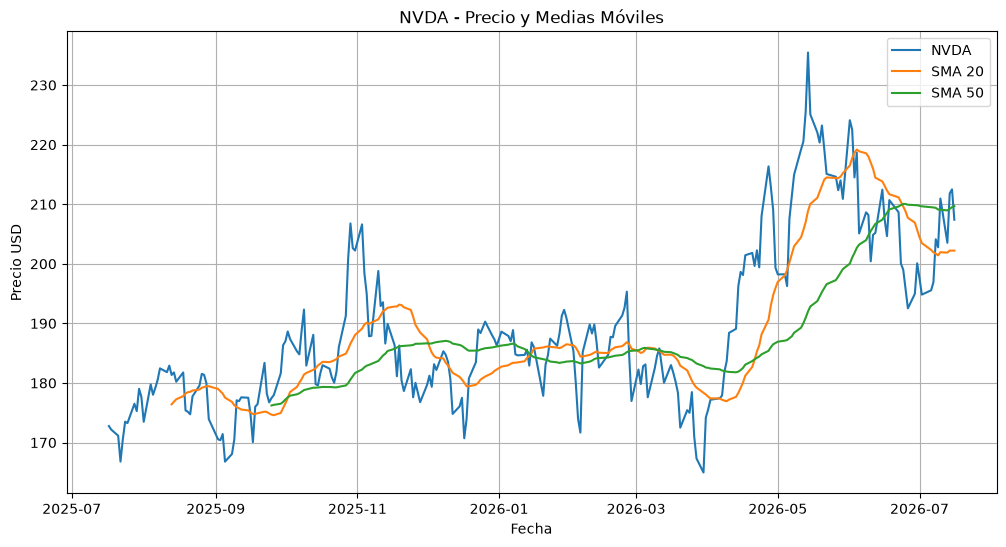

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    nvda.index,
    nvda["Close"],
    label="NVDA"
)

plt.plot(
    nvda.index,
    nvda["SMA20"],
    label="SMA 20"
)

plt.plot(
    nvda.index,
    nvda["SMA50"],
    label="SMA 50"
)


plt.title("NVDA - Precio y Medias Móviles")
plt.xlabel("Fecha")
plt.ylabel("Precio USD")

plt.legend()
plt.grid(True)

plt.show()

In [31]:
nvda["Signal"] = 0

nvda.loc[nvda["SMA20"] > nvda["SMA50"], "Signal"] = 1

nvda.loc[nvda["SMA20"] < nvda["SMA50"], "Signal"] = -1

nvda.tail()

Price,Close,High,Low,Open,Volume,Return,Cumulative Return,Portfolio,SMA20,SMA50,Signal
Date,,,,,,,,,,,
2026-07-10,210.960007,211.000000,201.919998,202.000000,148421000,0.040339,0.221046,12210.460839,201.951499,209.073742,-1
2026-07-13,203.529999,210.570007,203.000000,208.539993,121411000,-0.035220,0.178041,11780.408611,201.884499,208.964214,-1
2026-07-14,211.800003,212.550003,203.800003,208.199997,124379600,0.040633,0.225908,12259.080208,202.214999,209.213460,-1
2026-07-15,212.500000,213.809998,206.039993,211.960007,124797200,0.003305,0.229960,12299.596349,202.217500,209.499081,-1
2026-07-16,207.399994,211.080002,205.850006,210.169998,122377500,-0.024000,0.200441,12004.405683,202.216999,209.682102,-1
